In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('Fish.csv')

In [5]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [6]:
import matplotlib.pyplot as plt

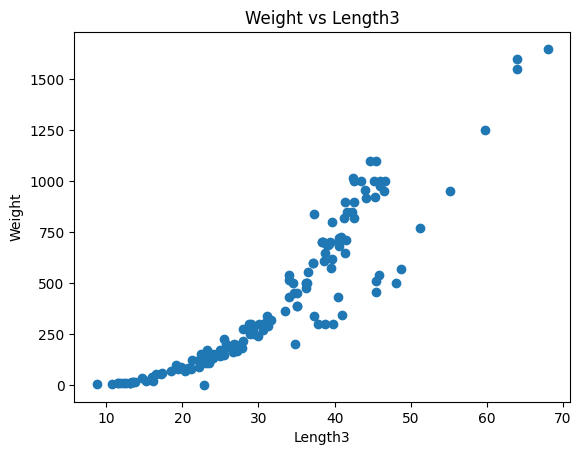

In [7]:
plt.scatter(df["Length3"], df["Weight"])
plt.xlabel("Length3")
plt.ylabel("Weight")
plt.title("Weight vs Length3")
plt.show()

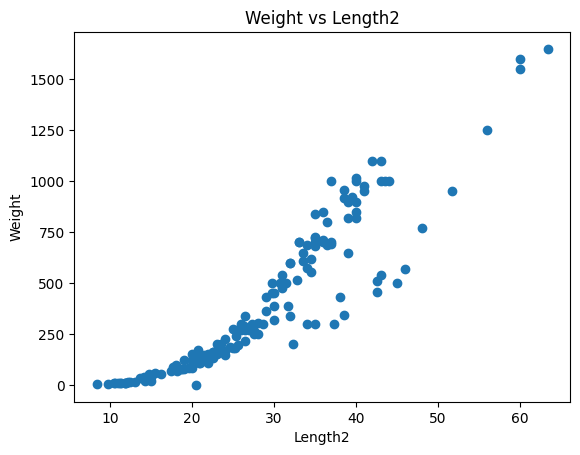

In [8]:
plt.scatter(df["Length2"], df["Weight"])
plt.xlabel("Length2")
plt.ylabel("Weight")
plt.title("Weight vs Length2")
plt.show()

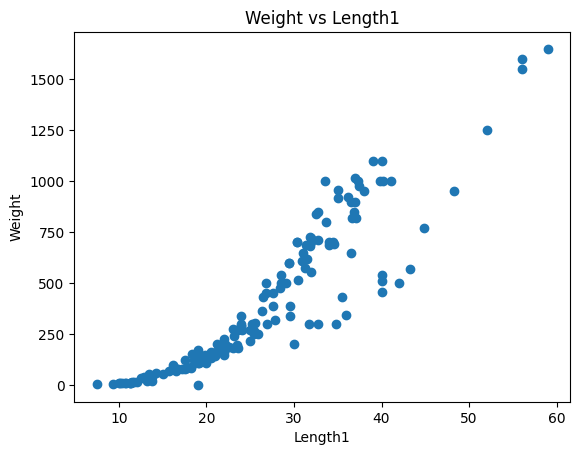

In [9]:
plt.scatter(df["Length1"], df["Weight"])
plt.xlabel("Length1")
plt.ylabel("Weight")
plt.title("Weight vs Length1")
plt.show()

In [10]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

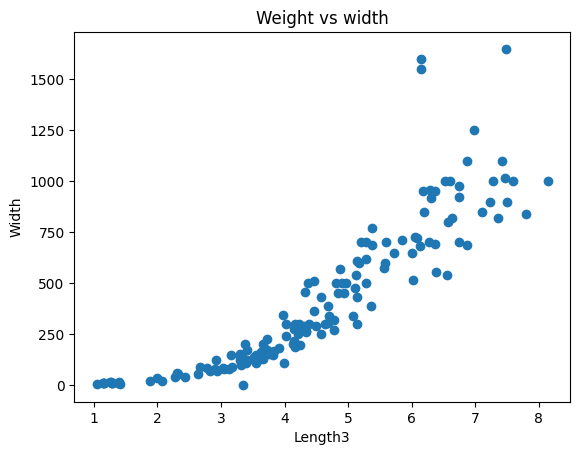

In [11]:
plt.scatter(df["Width"], df["Weight"])
plt.xlabel("Length3")
plt.ylabel("Width")
plt.title("Weight vs width")
plt.show()

In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [17]:
x=df[['Length3']]
y=df['Weight']
model=LinearRegression()

In [18]:
xtrain, xtest, ytrain, ytest= train_test_split(x,y, train_size=0.8, random_state=42)

In [19]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
model.coef_

array([28.4601708])

In [21]:
model.intercept_

np.float64(-490.4005915891796)

In [22]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
poly=PolynomialFeatures(degree=2)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest= poly.transform(xtest)
print(updated_xtrain)

[[1.00000e+00 1.72000e+01 2.95840e+02]
 [1.00000e+00 4.87000e+01 2.37169e+03]
 [1.00000e+00 3.11000e+01 9.67210e+02]
 [1.00000e+00 2.35000e+01 5.52250e+02]
 [1.00000e+00 2.53000e+01 6.40090e+02]
 [1.00000e+00 2.37000e+01 5.61690e+02]
 [1.00000e+00 2.41000e+01 5.80810e+02]
 [1.00000e+00 4.13000e+01 1.70569e+03]
 [1.00000e+00 4.06000e+01 1.64836e+03]
 [1.00000e+00 4.80000e+01 2.30400e+03]
 [1.00000e+00 1.16000e+01 1.34560e+02]
 [1.00000e+00 2.35000e+01 5.52250e+02]
 [1.00000e+00 2.32000e+01 5.38240e+02]
 [1.00000e+00 2.03000e+01 4.12090e+02]
 [1.00000e+00 2.25000e+01 5.06250e+02]
 [1.00000e+00 3.97000e+01 1.57609e+03]
 [1.00000e+00 2.28000e+01 5.19840e+02]
 [1.00000e+00 2.10000e+01 4.41000e+02]
 [1.00000e+00 3.90000e+01 1.52100e+03]
 [1.00000e+00 3.62000e+01 1.31044e+03]
 [1.00000e+00 3.40000e+01 1.15600e+03]
 [1.00000e+00 2.58000e+01 6.65640e+02]
 [1.00000e+00 4.66000e+01 2.17156e+03]
 [1.00000e+00 4.15000e+01 1.72225e+03]
 [1.00000e+00 1.26000e+01 1.58760e+02]
 [1.00000e+00 4.52000e+01

In [25]:
model=LinearRegression()
model.fit(updated_xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


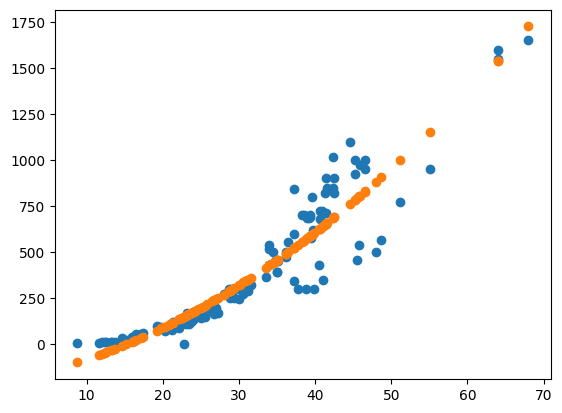

In [26]:
y_pred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],y_pred_train)

In [27]:
# Train Data
from sklearn.metrics import r2_score
train_score=r2_score(ytrain, y_pred_train)
print(f"train_score: {train_score}")

train_score: 0.8756695367609073


In [28]:
y_pred_test=model.predict(updated_xtest)
test_score=r2_score(ytest, y_pred_test)
print(f'test_score: {test_score}')

test_score: 0.8664863426509607


### Observation:

### When degree=2
### train_score: 0.8756695367609073
### test_score: 0.8664863426509607

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [ ]:
mae=mean_absolute_error(ytrain, y_pred_train)